In [ ]:
from __future__ import annotations

from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.messages import HumanMessage , SystemMessage
from langchain_community.tools.tavily_search import TavilySearchResults

from langgraph.graph import StateGraph , START , END
from langgraph.types import Send

from typing import TypedDict , List , Annotated , Literal , Optional
from pydantic import BaseModel , Field
from dotenv import load_dotenv
from pathlib import Path
import operator
import os
import re

d:\GenAI\LangGraph\myenvAI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
class  Task(BaseModel):

    id : int
    title : str

    goal : str = Field(
        ... , 
        description = 'One Sentence describe what the reader should be able to do/understand after this section'
    )

    bullets : List[str] = Field(
        ...,
        min_length = 3,
        max_length = 5,
        description = '3-5 concreate , non overlapping subpoint to cover in this section'
    )

    target_words : int = Field(
        ...,
        description = 'Target word count for this section (120-450)'
    )

    tags : List[str] = Field(default_factory=list)
    required_research : bool = False
    required_citation : bool = False
    required_code : bool = False



class Plan(BaseModel):
    blog_title : str
    tasks : List[Task]
    blog_kind : Literal['exlainer' , 'tutorial' , 'news_roundup' ,  'comparison'] = 'exlainer'
    constraints : List[str] = Field(default_factory=list)
    tone : str = Field(... , description = 'Writing tone (e.g , practical , crisp)')
    audience : str = Field(... , description = 'Who this blog is for.')


class EvidenceItem(BaseModel):
    title : str
    url : str
    published_at : Optional[str] = None
    snippet : Optional[str] = None
    source : Optional[str] = None

class RouterDecision(BaseModel):
    needs_research : bool
    mode : Literal['closed_book' , 'hybrid' , 'open_book']
    queries : List[str] = Field(default_factory=list)


class EvidencePack(BaseModel):
    evidence : List[EvidenceItem] = Field(default_factory=list)

In [4]:
# Define state
class State(TypedDict):
    topic : str
    mode  : str
    needs_research : bool
    queries : List[str]
    evidence : List[EvidenceItem]
    plan : Plan = Field(...)
    # reducer: result from workers get concatenated automatically
    sections : Annotated[List[tuple[int , str]] , operator.add]
    final : str

In [5]:
# from the LLM
llm = ChatNVIDIA(model = 'meta/llama-3.1-70b-instruct')

In [6]:
# ------------------------------------------

ROUTER_SYSTEM = '''

You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3–10 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.

'''
def router_node(state : State) -> dict:

    # print('\n From the router node \n')

    topic = state['topic']
    decider = llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content = ROUTER_SYSTEM),
            HumanMessage(content = f'Topic : {topic}')
        ]
    )

    return {

        'needs_research' : decision.needs_research,
        'mode' : decision.mode,
        'queries' : decision.queries
    }


def route_next(state : State) -> str:

    return 'research' if state['needs_research'] else 'orchestrator'


In [ ]:
# Research
def _tavily_search(query : str , max_results : int = 5) -> List[dict]:

    tool = TavilySearchResults(max_results = max_results)
    results = tool.invoke({'query' : query})

    normalized : List[dict] = []

    for r in results or []:
        normalized.append(
            {
                'title' : r.get('title') or '',
                'url' : r.get('url') or '',
                'snippet' : r.get('snippet') or r.get('content') or '',
                'published_at' : r.get('published_at') or r.get('published_date') or '',
                'source' : r.get('source') or '',
            }
        )


    return normalized



RESEARCH_SYSTEM = '''

You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
  If missing or unclear, set published_at=null. Do NOT guess.
- Keep snippets short.
- Deduplicate by URL.

'''

def research_node(state : State) -> dict:


    # take the first 10 queries from state
    queries = (state.get('queries' , [])  or [])
    max_results = 6

    raw_results : List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q , max_results = max_results))

    if not raw_results:
        return {'evidence' : []}
    
    extractor = llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content = RESEARCH_SYSTEM),
            HumanMessage(content = f'Raw result : \n {raw_results}')
        ]
    )

    # Deduplicate by url
    dedup = {}

    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e

    return {'evidence' : list(dedup.values())}

In [8]:
def orchestrator(state : State) -> dict:


    planner = llm.with_structured_output(Plan)

    evidence = state.get('evidence' , [])
    mode = state.get('mode' , [])

    
    
    
    plan = planner.invoke(
        [
            SystemMessage(content =
                          (

                    "You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5-7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                    "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema."
                )
            ),
            HumanMessage(
                content = (
                    f'Topic : {state["topic"]}\n'
                    f'Mode : {state["mode"]}\n'
                    f'Evidence (ONLY use for fresh claims; may be empty) : \n'
                    f'{[e for e in evidence][:16]}\n'
                    
                    
                )
            ),
        ]
    )

    return {'plan' : plan}

In [9]:
def fanout(state : State):

    return [
        Send(
            'worker' , 
            {
                'task' : task , 
                'topic' : state['topic'] ,
                'mode' : state['mode'],
                'iteration' : i,
                'plan' : state['plan'],
                'evidence' : [e for e in state.get('evidence' , [])]
                
            },
        )
        for i , task in enumerate(state['plan'].tasks)
    ]

In [ ]:


def worker_node(payload : dict) -> dict:


    # payload contrain what we want
    task = payload['task']
    plan = payload['plan']
    iteration = payload.get('iteration')
    evidence = [EvidenceItem(e) for e in payload.get('evidence' , [])]
    topic = payload['topic']
    mode = payload['mode']


    bullets_text = '\n-' + '\n-'.join(task.bullets)

    evidence_text = ''
    if evidence:
        evidence_text = '\n'.join(

            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}".strip()
            for e in evidence[:20]
        )

    section_md = llm.invoke(
        [

            SystemMessage(
                content =(
                    "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
                    "Hard constraints:\n"
                    "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
                    "- Stay close to the Target words (±15%).\n"
                    "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
                    "Technical quality bar:\n"
                    "- Be precise and implementation-oriented (developers should be able to apply it).\n"
                    "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
                    "- When relevant, include at least one of:\n"
                    "  * a small code snippet (minimal, correct, and idiomatic)\n"
                    "  * a tiny example input/output\n"
                    "  * a checklist of steps\n"
                    "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
                    "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
                    "- Call out edge cases / failure modes and what to do about them.\n"
                    "- If you mention a best practice, add the 'why' in one sentence.\n\n"
                    "Markdown style:\n"
                    "- Start with a '## <Section Title>' heading.\n"
                    "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
                    "- Avoid fluff. Avoid marketing language.\n"
                    "- If you include code, keep it focused on the bullet being addressed.\n"
                )
            ),
            HumanMessage(
                content = (
                    f'Blog title : {plan.blog_title}\n'
                    f'Audience : {plan.audience}\n'
                    f'Tone : {plan.tone}\n'
                    f'Blog_kind : {plan.blog_kind}\n'
                    f'Constraint : {plan.constraints}\n'
                    f'Topic : {topic}\n'
                    f'Mode : {mode}\n'
                    f'Section title : {task.title}\n'
                    f'Goal : {task.goal}\n'
                    f'Tags : {task.tags}\n'
                    f'Required_research : {task.required_research}\n'
                    f'Required_ciations : {task.required_citation}\n'
                    f'Required_code : {task.required_code}\n'
                    f'Target_words : {task.target_words}\n'
                    f'Bullets : {bullets_text}\n'
                    f'Evidence (ONLY use these URLs when citing):\n {evidence_text}\n'
                )
            ),
        ]
    ).content.strip()

    section_md = (iteration , section_md)

    return {'sections' : [section_md]}

In [17]:
# Reducer (Merge + Save)
def reducer_node(state : State) -> dict:

    plan = state['plan']


    ordered_sections = [md for _ , md in sorted(state['sections'] , key = lambda x : x[0])]
    body = '\n\n'.join(ordered_sections).strip()

    title = state.get('plan').blog_title

    final_md = f'# {title}\n\n{body}'




    print('\n\n\n\n ======  Final Markdown ==============\n\n\n\n')

    print(final_md)



    filename = re.sub(r'[<>:"/\\|?*]', "", title)
    filename = filename.replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md , encoding='utf-8')


    return {'final' : final_md}

In [18]:
# Define graph
builder = StateGraph(State)

# Add nodes
builder.add_node('router' , router_node)
builder.add_node('research' , research_node)
builder.add_node('orchestrator' , orchestrator)
builder.add_node('worker' , worker_node)
builder.add_node('reducer' , reducer_node)

# Add edges
builder.add_edge(START , 'router')
builder.add_conditional_edges('router' , route_next , {'research' : 'research' , 'orchestrator' : 'orchestrator'})
builder.add_edge('research' , 'orchestrator')
builder.add_conditional_edges('orchestrator' , fanout , ['worker'])
builder.add_edge('worker' , 'reducer')
builder.add_edge('reducer' , END)

# compile the graph
agent = builder.compile()

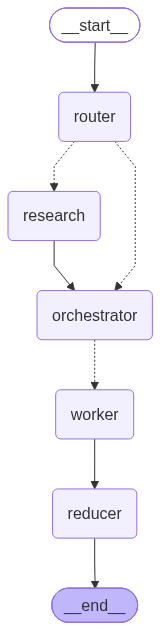

In [19]:
agent

In [20]:
def run(topic : str):

    out = agent.invoke(
        {
            'topic' : topic,
            'mode' : '',
            'needs_research' : False,
            'queries' : [],
            'evidence' : [],
            'plan' : None,
            'sections' : [],
            'final' : ''
        }
    )

    return out

In [ ]:
out = run('Top news in AI of this months')

print(out)